# NAIVE BAYE'S  <br>
REGRESSION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Generate random data
np.random.seed(42)

X = np.random.rand(100, 1) * 10  # Feature values between 0 and 10

# Target = 3*x + noise
y = 3 * X.squeeze() + np.random.randn(100) * 2

# Create DataFrame
dataset = pd.DataFrame({
    'Feature': X.squeeze(),
    'Target': y
})

print(dataset.head())

    Feature     Target
0  3.745401  11.410298
1  9.507143  27.923414
2  7.319939  22.143340
3  5.986585  13.984617
4  1.560186   4.241215


In [ ]:
# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Train the KNN Regression Model
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [ ]:
# Make Predictions

y_pred = knn.predict(X_test)

In [ ]:
# Evaluate the Model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 3.6046097253613296
R² Score: 0.956761388757069


In [ ]:
# Predict a New Value

new_data = np.array([[6.5]])

prediction = knn.predict(new_data)

print("Prediction for x = 6.5:", prediction[0])

Prediction for x = 6.5: 18.527705711743234


findfont: Failed to find font weight normal, now using 700.
findfont: Failed to find font weight normal, now using 700.


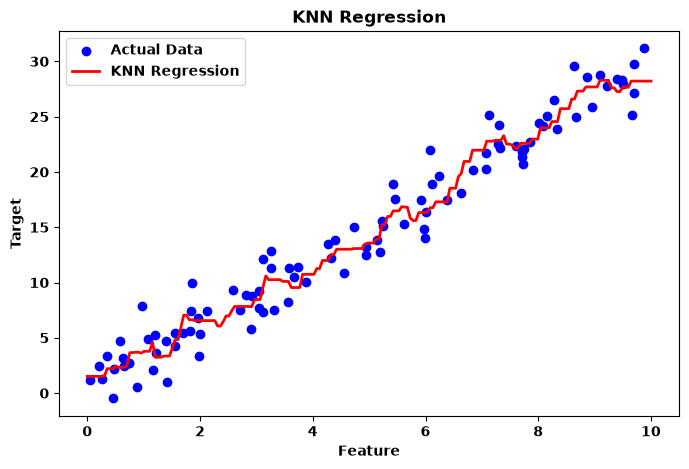

In [ ]:
# Visualize the Results

plt.figure(figsize=(8,5))

# Scatter plot of original data
plt.scatter(X, y, color='blue', label='Actual Data')

# Smooth prediction curve
X_range = np.linspace(0, 10, 200).reshape(-1,1)
y_range = knn.predict(X_range)

plt.plot(X_range, y_range, color='red', linewidth=2, label='KNN Regression')

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("KNN Regression")
plt.legend()
plt.show()